## IMPORTING VARIABLES

In [ ]:
import pandas as pd
import numpy as np
from dotenv import load_dotenv
import os
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import ccf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.stattools import acf, pacf
from scipy.stats import norm
from statsmodels.tsa.arima.model import ARIMA
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from hmmlearn import hmm
from sklearn.metrics import accuracy_score, confusion_matrix
from itertools import product


load_dotenv()

In [ ]:
# Carregar variáveis de ambiente
load_dotenv()

path_dados_tratados = os.getenv('PATH_DADOS_TRATADOS')

resultado_bruto = pd.read_csv(f"{path_dados_tratados}resultado_bruto.csv", index_col=0, parse_dates=True)
lucro_consolidado = pd.read_csv(f"{path_dados_tratados}lucro_consolidado.csv", index_col=0, parse_dates=True)
despesas_operacionais = pd.read_csv(f"{path_dados_tratados}despesas_operacionais.csv", index_col=0, parse_dates=True)
input_receita = {}
exog_vars_estac_lags = {}
dados_indices = {}
for empresa in resultado_bruto.columns:
    input_receita[empresa] = pd.read_csv(f"{path_dados_tratados}input_receita_{empresa}.csv", index_col=0, parse_dates=True)
    input_receita[empresa].index = pd.to_datetime(input_receita[empresa].index, format='%Y-%m-%d')
    exog_vars_estac_lags[empresa] = pd.read_csv(f"{path_dados_tratados}exog_vars_estac_lags_{empresa}.csv", index_col=0, parse_dates=True)
    exog_vars_estac_lags[empresa].index = pd.to_datetime(exog_vars_estac_lags[empresa].index, format='%Y-%m-%d')
    dados_indices[empresa] = pd.read_csv(f"{path_dados_tratados}dados_indices.csv", index_col=1, parse_dates=True, sep=';')
    dados_indices[empresa].drop(columns=['Unnamed: 0'], inplace=True)

## Gaussian HMM

Prepara para a GaussianHMM

In [ ]:
def preparar_serie_gaussianhmm(serie, aplicar_log=True, diferenciacao=1, usar_log_returns=False):
    """
    Prepares time series for GaussianHMM: makes it stationary and applies log.
    
    Args:
        serie: time series (pandas Series)
        aplicar_log: if True, applies log after making positive
        diferenciacao: differentiation order (1 = first difference)
    
    Returns:
        tuple: (serie_transformada, serie_original_limpa, transformacoes_aplicadas)
    """
    # Clean series
    serie_limpa = (
        serie
        .sort_index()
        .astype(float)
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )
    
    transformacoes = []
    serie_transformada = serie_limpa.copy()

    if usar_log_returns:
        serie_transformada = np.log(serie_limpa).diff().dropna()
        transformacoes.append('Log-return (ln p_t - ln p_{t-1})')
        return serie_transformada, serie_limpa, transformacoes
    
    # Make values positive (required for log)
    if aplicar_log:
        min_val = serie_transformada.min()
        if min_val <= 0:
            shift_value = abs(min_val) + 1
            serie_transformada = serie_transformada + shift_value
            transformacoes.append(f'Shift +{shift_value:.2f}')
        
        # Apply log
        serie_transformada = np.log(serie_transformada)
        transformacoes.append('Natural Log')
    
    # Differentiation for stationarity
    if diferenciacao > 0:
        for _ in range(diferenciacao):
            serie_transformada = serie_transformada.diff().dropna()
            transformacoes.append('1st Order Differencing')
    
    return serie_transformada, serie_limpa, transformacoes

def testar_estacionariedade(serie, nome='Series', alpha=0.05):
    """
    Tests stationarity using ADF and KPSS.
    
    Args:
        serie: time series
        nome: series name
        alpha: significance level
    
    Returns:
        dict with test results
    """
    from statsmodels.tsa.stattools import adfuller, kpss
    
    # ADF test (H0: series has unit root = non-stationary)
    adf_result = adfuller(serie.dropna(), autolag='AIC')
    adf_estatistica, adf_pvalue = adf_result[0], adf_result[1]
    adf_estacionaria = adf_pvalue < alpha
    
    # KPSS test (H0: series is stationary)
    kpss_result = kpss(serie.dropna(), regression='c', nlags='auto')
    kpss_estatistica, kpss_pvalue = kpss_result[0], kpss_result[1]
    kpss_estacionaria = kpss_pvalue > alpha
    
    return {
        'nome': nome,
        'adf_estatistica': adf_estatistica,
        'adf_pvalue': adf_pvalue,
        'adf_estacionaria': adf_estacionaria,
        'kpss_estatistica': kpss_estatistica,
        'kpss_pvalue': kpss_pvalue,
        'kpss_estacionaria': kpss_estacionaria,
        'conclusao_estacionaria': adf_estacionaria and kpss_estacionaria
    }

def analisar_gaussianhmm(serie, nome_serie='Series', n_estados=3, n_iter=100, 
                          aplicar_log=True, diferenciacao=1, random_state=1):
    """
    Trains GaussianHMM on transformed series and returns results.
    
    Args:
        serie: original time series
        nome_serie: series name
        n_estados: number of hidden states
        n_iter: Baum-Welch iterations
        aplicar_log: if True, applies log
        diferenciacao: differentiation order
        random_state: seed for reproducibility
    
    Returns:
        dict with trained model, states, series and statistics
    """
    # Prepare series
    serie_transformada, serie_original, transformacoes = preparar_serie_gaussianhmm(
        serie, aplicar_log, diferenciacao, usar_log_returns=True
    )
    
    # Test stationarity
    teste_estacionariedade = testar_estacionariedade(serie_transformada, nome_serie)
    
    # Prepare data for HMM (must be 2D)
    obs_sequencia = serie_transformada.to_numpy().reshape(-1, 1)
    
    # Train model
    model = hmm.GaussianHMM(
        n_components=n_estados,
        covariance_type='full',
        n_iter=n_iter,
        random_state=random_state,
        verbose=False
    )
    model.fit(obs_sequencia)
    
    # Decode states
    logprob, estados_preditos = model.decode(obs_sequencia)
    
    # Calculate statistics per state
    estatisticas_estados = []
    for estado in range(n_estados):
        mascara = estados_preditos == estado
        valores_estado = serie_transformada[mascara]
        
        estatisticas_estados.append({
            'estado': estado,
            'n_observacoes': mascara.sum(),
            'percentual': (mascara.sum() / len(estados_preditos)) * 100,
            'media': valores_estado.mean(),
            'desvio_padrao': valores_estado.std(),
            'min': valores_estado.min(),
            'max': valores_estado.max()
        })
    
    return {
        'nome': nome_serie,
        'serie_original': serie_original,
        'serie_transformada': serie_transformada,
        'transformacoes': transformacoes,
        'estados': estados_preditos,
        'index': serie_transformada.index,
        'modelo': model,
        'convergiu': model.monitor_.converged,
        'log_likelihood': model.monitor_.history[-1] if model.monitor_.history else np.nan,
        'teste_estacionariedade': teste_estacionariedade,
        'estatisticas_estados': pd.DataFrame(estatisticas_estados),
        'n_estados': n_estados
    }

def plotar_resultados_gaussianhmm(resultado, figsize=(15, 12)):
    """
    Plots complete GaussianHMM results.
    
    Args:
        resultado: dict returned by analisar_gaussianhmm
        figsize: figure size
    """
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(4, 2, hspace=0.3, wspace=0.3)
    
    # 1. Original Series
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(resultado['serie_original'].index, resultado['serie_original'], 
             color='steelblue', linewidth=1.5, label='Original Series')
    ax1.set_title(f"{resultado['nome']} - Original Series", fontsize=13, fontweight='bold')
    ax1.set_ylabel('Value', fontsize=11)
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='upper left')
    
    # 2. Transformed Series with States
    ax2 = fig.add_subplot(gs[1, :])
    ax2.plot(resultado['index'], resultado['serie_transformada'], 
             color='navy', linewidth=1, alpha=0.7, label='Transformed Series')
    
    # Color by state
    cores_estados = ['crimson', 'orange', 'green', 'purple', 'brown']
    for estado in range(resultado['n_estados']):
        mascara = resultado['estados'] == estado
        ax2.scatter(resultado['index'][mascara], 
                   resultado['serie_transformada'][mascara],
                   c=cores_estados[estado % len(cores_estados)], 
                   s=30, alpha=0.6, label=f'State {estado}')
    
    transformacoes_str = ' → '.join(resultado['transformacoes'])
    ax2.set_title(f"Transformed Series ({transformacoes_str})", fontsize=13, fontweight='bold')
    ax2.set_ylabel('Transformed Value', fontsize=11)
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc='upper left', fontsize=9)
    
    # 3. States over time
    ax3 = fig.add_subplot(gs[2, :])
    ax3.step(resultado['index'], resultado['estados'], where='mid', 
             color='crimson', linewidth=2, label='Predicted States')
    ax3.set_title('Hidden States Over Time', fontsize=13, fontweight='bold')
    ax3.set_xlabel('Time', fontsize=11)
    ax3.set_ylabel('State', fontsize=11)
    ax3.set_yticks(range(resultado['n_estados']))
    ax3.set_yticklabels([f'State {i}' for i in range(resultado['n_estados'])])
    ax3.grid(True, alpha=0.3)
    ax3.legend()
    
    # 4. Value distribution per state
    ax4 = fig.add_subplot(gs[3, 0])
    for estado in range(resultado['n_estados']):
        mascara = resultado['estados'] == estado
        valores = resultado['serie_transformada'][mascara]
        ax4.hist(valores, bins=20, alpha=0.5, 
                label=f'State {estado}', 
                color=cores_estados[estado % len(cores_estados)])
    
    ax4.set_title('Distribution by State', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Transformed Value', fontsize=10)
    ax4.set_ylabel('Frequency', fontsize=10)
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    # 5. Boxplot per state
    ax5 = fig.add_subplot(gs[3, 1])
    dados_boxplot = [
        resultado['serie_transformada'][resultado['estados'] == estado]
        for estado in range(resultado['n_estados'])
    ]
    bp = ax5.boxplot(dados_boxplot, labels=[f'State {i}' for i in range(resultado['n_estados'])],
                     patch_artist=True)
    
    for patch, cor in zip(bp['boxes'], cores_estados):
        patch.set_facecolor(cor)
        patch.set_alpha(0.6)
    
    ax5.set_title('Statistics by State', fontsize=12, fontweight='bold')
    ax5.set_ylabel('Transformed Value', fontsize=10)
    ax5.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

def resumo_gaussianhmm(resultado):
    """Displays detailed GaussianHMM model summary"""
    print("\n" + "="*70)
    print(f"GAUSSIANHMM MODEL SUMMARY - {resultado['nome']}")
    print("="*70)
    
    print(f"\n--- Applied Transformations ---")
    for i, transf in enumerate(resultado['transformacoes'], 1):
        print(f"{i}. {transf}")
    
    print(f"\n--- Stationarity Test ---")
    teste = resultado['teste_estacionariedade']
    print(f"ADF p-value: {teste['adf_pvalue']:.4f} {'✔ Stationary' if teste['adf_estacionaria'] else '✗ Non-stationary'}")
    print(f"KPSS p-value: {teste['kpss_pvalue']:.4f} {'✔ Stationary' if teste['kpss_estacionaria'] else '✗ Non-stationary'}")
    print(f"Conclusion: {'✔ STATIONARY SERIES' if teste['conclusao_estacionaria'] else '✗ NON-STATIONARY SERIES'}")
    
    print(f"\n--- Model Information ---")
    print(f"Converged: {resultado['convergiu']}")
    print(f"Log-Likelihood: {resultado['log_likelihood']:.2f}")
    print(f"Number of observations: {len(resultado['estados'])}")
    print(f"Number of states: {resultado['n_estados']}")
    
    print(f"\n--- Transition Matrix ---")
    print(resultado['modelo'].transmat_.round(3))
    
    print(f"\n--- Means by State ---")
    print(resultado['modelo'].means_.round(3))
    
    print(f"\n--- Covariances by State ---")
    for i in range(resultado['n_estados']):
        print(f"\nState {i}:")
        print(resultado['modelo'].covars_[i].round(3))
    
    print(f"\n--- Descriptive Statistics by State ---")
    print(resultado['estatisticas_estados'].to_string(index=False))
    print("="*70)

def comparar_multiplos_indicadores_gaussianhmm(empresa, indicadores_dict, n_estados=3, 
                                                aplicar_log=True, diferenciacao=1, n_iter=100):
    """
    Analyzes multiple indicators with GaussianHMM and compares results.
    
    Args:
        empresa: company code
        indicadores_dict: dictionary {'name': time_series}
        n_estados: number of states
        aplicar_log: apply logarithm
        diferenciacao: differentiation order
        n_iter: Baum-Welch iterations
    
    Returns:
        dict with results per indicator
    """
    resultados = {}
    
    for nome, serie in indicadores_dict.items():
        print(f"\n{'='*70}")
        print(f"Processing: {nome}")
        print('='*70)
        
        resultado = analisar_gaussianhmm(
            serie=serie,
            nome_serie=f"{nome} - Company {empresa}",
            n_estados=n_estados,
            aplicar_log=aplicar_log,
            diferenciacao=diferenciacao,
            n_iter=n_iter
        )
        
        resultados[nome] = resultado
        
        # Display summary
        resumo_gaussianhmm(resultado)
        
        # Plot results
        plotar_resultados_gaussianhmm(resultado)
    
    return resultados


In [ ]:
# Analysis of multiple indicators
empresa_analise = '21490'

indicadores = {
    'Gross Income': resultado_bruto[empresa_analise],
    'Gross Profit': lucro_consolidado[empresa_analise],
    'Operational Expenses': despesas_operacionais[empresa_analise]
}

resultados_gaussian = comparar_multiplos_indicadores_gaussianhmm(
    empresa=empresa_analise,
    indicadores_dict=indicadores,
    n_estados=3,
    aplicar_log=True,
    diferenciacao=1,
    n_iter=100
)

# Consolidated state comparison
print("\n" + "="*70)
print("CONSOLIDATED COMPARISON - STATES BY INDICATOR")
print("="*70)

for nome, resultado in resultados_gaussian.items():
    print(f"\n{nome}:")
    print(resultado['estatisticas_estados'][['estado', 'n_observacoes', 'percentual', 'media']].to_string(index=False))


In [ ]:
def gaussianhmm_one_step_ahead(serie, nome_serie='Series', n_estados=3, janela_treino=18,
                                aplicar_log=True, diferenciacao=1, n_iter=100, random_state=1):
    """
    Trains GaussianHMM with one-step-ahead validation.
    
    Args:
        serie: original time series
        nome_serie: series name
        n_estados: number of hidden states
        janela_treino: number of initial observations for training
        aplicar_log: apply logarithm
        diferenciacao: differentiation order
        n_iter: Baum-Welch iterations
        random_state: seed for reproducibility
    
    Returns:
        dict with predictions, real vs predicted states and metrics
    """
    # Prepare series
    serie_transformada, serie_original, transformacoes = preparar_serie_gaussianhmm(
        serie, aplicar_log, diferenciacao, usar_log_returns=True
    )
    
    # Test stationarity
    teste_estacionariedade = testar_estacionariedade(serie_transformada, nome_serie)
    
    obs_sequencia = serie_transformada.to_numpy()
    index_obs = serie_transformada.index
    
    if len(obs_sequencia) <= janela_treino:
        raise ValueError(f"Series has only {len(obs_sequencia)} observations. Required > {janela_treino}")
    
    # Lists to store results
    estados_reais = []
    estados_preditos = []
    valores_reais = []
    valores_preditos = []
    probabilidades = []
    indices = []
    
    print(f"\n{'='*70}")
    print(f"ONE-STEP-AHEAD GAUSSIANHMM - {nome_serie}")
    print(f"{'='*70}")
    print(f"Initial training window: {janela_treino} observations")
    print(f"Total predictions (out-of-sample): {len(obs_sequencia) - janela_treino}")
    print(f"Transformations: {' → '.join(transformacoes)}")
    print(f"Stationary series: {'✔ YES' if teste_estacionariedade['conclusao_estacionaria'] else '✗ NO'}")
    print('='*70)
    
    # Rolling prediction loop (STARTS FROM TRAINING WINDOW)
    for i in range(janela_treino, len(obs_sequencia)):
        # Training data (sliding window - ALL data up to i)
        treino = obs_sequencia[:i].reshape(-1, 1)
        
        # Train model
        model = hmm.GaussianHMM(
            n_components=n_estados,
            covariance_type='full',
            n_iter=n_iter,
            random_state=random_state,
            verbose=False
        )
        
        try:
            model.fit(treino)
            
            # Decode states of training set
            _, estados_treino = model.decode(treino)
            estado_atual = estados_treino[-1]
            
            # Predict next state using transition matrix
            probs_prox_estado = model.transmat_[estado_atual]
            estado_predito = int(np.argmax(probs_prox_estado))
            
            # Predict next value using mean of predicted state
            valor_predito = model.means_[estado_predito][0]
            
            # Real value (out-of-sample)
            valor_real = obs_sequencia[i]
            
            # Store results
            estados_reais.append(estado_atual)   # Current state (t)
            estados_preditos.append(estado_predito)  # Predicted state (t+1)
            valores_reais.append(valor_real)
            valores_preditos.append(valor_predito)
            probabilidades.append(probs_prox_estado[estado_predito])
            indices.append(index_obs[i])
            
            if (i - janela_treino + 1) % 10 == 0:
                print(f"Prediction {i-janela_treino+1}/{len(obs_sequencia)-janela_treino}: "
                      f"Current_state={estado_atual}, Pred_state={estado_predito}, "
                      f"Prob={probs_prox_estado[estado_predito]:.3f}")
        
        except Exception as e:
            print(f"Error at iteration {i}: {str(e)}")
            continue
    
    # Check if there are predictions
    if len(valores_reais) == 0:
        raise ValueError("No predictions were made!")
    
    # Create DataFrame with results (OUT-OF-SAMPLE PREDICTIONS ONLY)
    df_resultados = pd.DataFrame({
        'estado_atual': estados_reais,
        'estado_predito': estados_preditos,
        'valor_real': valores_reais,
        'valor_predito': valores_preditos,
        'probabilidade': probabilidades
    }, index=indices)
    
    # Calculate metrics (OUT-OF-SAMPLE DATA ONLY)
    acuracia_estados = accuracy_score(estados_reais, estados_preditos)
    
    # Convert to numpy arrays for calculations
    valores_reais_arr = np.array(valores_reais)
    valores_preditos_arr = np.array(valores_preditos)
    
    mse = mean_squared_error(valores_reais_arr, valores_preditos_arr)
    rmse_bruto = np.sqrt(mse)
    faixa = valores_reais_arr.max() - valores_reais_arr.min()
    nrmse = rmse_bruto / faixa if faixa != 0 else np.nan
    mae = np.mean(np.abs(valores_reais_arr - valores_preditos_arr))
    
    # Correlation between real and predicted values
    if len(valores_reais) > 1:
        correlacao = np.corrcoef(valores_reais_arr, valores_preditos_arr)[0, 1]
    else:
        correlacao = np.nan
    
    print(f"\n{'='*70}")
    print("VALIDATION RESULTS (OUT-OF-SAMPLE)")
    print('='*70)
    print(f"Number of predictions: {len(df_resultados)}")
    print(f"State Accuracy: {acuracia_estados:.4f}")
    print(f"RMSE (raw): {rmse_bruto:.4f}")
    print(f"NRMSE (range): {nrmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"Correlation: {correlacao:.4f}")
    print('='*70)
    
    return {
        'nome': nome_serie,
        'serie_original': serie_original,
        'serie_transformada': serie_transformada,
        'transformacoes': transformacoes,
        'teste_estacionariedade': teste_estacionariedade,
        'df_resultados': df_resultados,
        'metricas': {
            'acuracia_estados': acuracia_estados,
            'nrmse': nrmse,
            'rmse_bruto': rmse_bruto,
            'mae': mae,
            'correlacao': correlacao,
            'n_predicoes': len(df_resultados)
        },
        'n_estados': n_estados,
        'janela_treino': janela_treino,
        'modelo': model
    }
      

def plotar_validacao_gaussianhmm(resultado_validacao, figsize=(15, 8)):
    """
    Plots:
      1) Real vs predicted values on the transformed series (log-return)
      2) Predicted values converted back to original scale vs real series
    """
    df = resultado_validacao['df_resultados'].copy()
    metricas = resultado_validacao['metricas']
    serie_original = resultado_validacao['serie_original']
    idx_original = serie_original.index

    # Convert predictions back (log-return -> original level): p_hat_t = p_{t-1} * exp(r_hat)
    pred_orig = []
    real_orig = []
    for t, r_hat in zip(df.index, df['valor_predito']):
        try:
            pos = idx_original.get_loc(t)
            if pos > 0:
                p_prev = serie_original.iloc[pos - 1]
                pred_orig.append(p_prev * np.exp(r_hat))
            else:
                pred_orig.append(np.nan)
            real_orig.append(serie_original.iloc[pos])
        except Exception:
            pred_orig.append(np.nan)
            real_orig.append(np.nan)

    df['valor_predito_orig'] = pred_orig
    df['valor_real_orig'] = real_orig

    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True)
    fig.subplots_adjust(hspace=0.25)

    # 1) Transformed series (log-returns)
    ax1 = axes[0]
    ax1.plot(df.index, df['valor_real'], 'o-', color='navy', linewidth=1.5, markersize=4,
             label='Real Value (log-ret)', alpha=0.7)
    ax1.plot(df.index, df['valor_predito'], 's--', color='crimson', linewidth=1.5, markersize=4,
             label='Predicted Value (log-ret)', alpha=0.7)
    ax1.set_title(f"Transformed (log-return) - NRMSE: {metricas.get('nrmse', np.nan):.4f}",
                  fontsize=12, fontweight='bold')
    ax1.set_ylabel('Log-return', fontsize=11)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2) Original scale
    ax2 = axes[1]
    ax2.plot(df.index, df['valor_real_orig'], 'o-', color='steelblue', linewidth=1.5, markersize=4,
             label='Real Value (orig)', alpha=0.7)
    ax2.plot(df.index, df['valor_predito_orig'], 's--', color='darkorange', linewidth=1.5, markersize=4,
             label='Predicted Value (orig)', alpha=0.7)
    ax2.set_title("Original Scale (reconstructed from log-return)", fontsize=12, fontweight='bold')
    ax2.set_xlabel('Time', fontsize=11)
    ax2.set_ylabel('Value', fontsize=11)
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def grid_search_gaussianhmm_validacao(serie, nome_serie='Series', 
                                      estados_range=(2, 6), 
                                      janela_treino=18,
                                      n_iter=100, 
                                      random_states=None,
                                      aplicar_log=True, 
                                      diferenciacao=1):
    """
    Grid search for GaussianHMM with one-step-ahead validation.
    
    Args:
        serie: original time series
        nome_serie: series name
        estados_range: tuple (min, max) for number of states
        janela_treino: number of initial observations for training
        n_iter: Baum-Welch iterations
        random_states: list of seeds (default: 10 random values)
        aplicar_log: apply logarithm
        diferenciacao: differentiation order
    
    Returns:
        dict with results and best model
    """
    if random_states is None:
        np.random.seed(42)
        random_states = np.random.randint(1, 1000, size=10).tolist()
    
    print(f"\n{'='*70}")
    print(f"GRID SEARCH WITH ONE-STEP-AHEAD VALIDATION - {nome_serie}")
    print(f"{'='*70}")
    print(f"Testing {len(range(estados_range[0], estados_range[1]))} state configurations")
    print(f"With {len(random_states)} different initial points")
    print(f"Training window: {janela_treino}")
    print('='*70)
    
    resultados = []
    
    for n_estados in range(estados_range[0], estados_range[1]):
        for seed in random_states:
            try:
                resultado = gaussianhmm_one_step_ahead(
                    serie=serie,
                    nome_serie=nome_serie,
                    n_estados=n_estados,
                    janela_treino=janela_treino,
                    aplicar_log=aplicar_log,
                    diferenciacao=diferenciacao,
                    n_iter=n_iter,
                    random_state=seed
                )
                
                resultados.append({
                   'n_estados': n_estados,
                    'random_state': seed,
                    'acuracia_estados': resultado['metricas']['acuracia_estados'],
                    'nrmse': resultado['metricas']['nrmse'],
                    'mae': resultado['metricas']['mae'],
                    'correlacao': resultado['metricas']['correlacao'],
                    'resultado_completo': resultado
                })
                
                print(f"\nStates={n_estados}, Seed={seed:3d} → "
                      f"Acc={resultado['metricas']['acuracia_estados']:.3f}, "
                      f"NRMSE={resultado['metricas']['nrmse']:.4f}, "
                      f"Corr={resultado['metricas']['correlacao']:.3f}")
                
            except Exception as e:
                print(f"\nStates={n_estados}, Seed={seed} → ERROR: {str(e)}")
                continue
    
    if not resultados:
        raise ValueError("No model was successfully trained!")
    
    # Create DataFrame with results
    df_resultados = pd.DataFrame([
        {
            'n_estados': r['n_estados'],
            'random_state': r['random_state'],
            'acuracia_estados': r['acuracia_estados'],
            'nrmse': r['nrmse'],
            'mae': r['mae'],
            'correlacao': r['correlacao']
        }
        for r in resultados
    ])
    
    # Identify best models
    melhor_acuracia_idx = df_resultados['acuracia_estados'].idxmax()
    melhor_nrmse_idx = df_resultados['nrmse'].idxmin()
    melhor_correlacao_idx = df_resultados['correlacao'].idxmax()
    
    melhor_acuracia = resultados[melhor_acuracia_idx]['resultado_completo']
    melhor_nrmse = resultados[melhor_nrmse_idx]['resultado_completo']
    melhor_correlacao = resultados[melhor_correlacao_idx]['resultado_completo']
    
    print(f"\n{'='*70}")
    print("RESULTS SUMMARY")
    print('='*70)
    print(f"\n✔ BEST MODEL BY STATE ACCURACY:")
    print(f"  States: {melhor_acuracia['n_estados']}")
    print(f"  Accuracy: {melhor_acuracia['metricas']['acuracia_estados']:.4f}")
    print(f"  NRMSE: {melhor_acuracia['metricas']['nrmse']:.4f}")
    
    print(f"\n✔ BEST MODEL BY NRMSE:")
    print(f"  States: {melhor_nrmse['n_estados']}")
    print(f"  NRMSE: {melhor_nrmse['metricas']['nrmse']:.4f}")
    print(f"  Accuracy: {melhor_nrmse['metricas']['acuracia_estados']:.4f}")
    
    print(f"\n✔ BEST MODEL BY CORRELATION:")
    print(f"  States: {melhor_correlacao['n_estados']}")
    print(f"  Correlation: {melhor_correlacao['metricas']['correlacao']:.4f}")
    print(f"  NRMSE: {melhor_correlacao['metricas']['nrmse']:.4f}")
    print('='*70)
    
    return {
        'nome': nome_serie,
        'df_resultados': df_resultados,
        'todos_resultados': resultados,
        'melhor_acuracia': melhor_acuracia,
        'melhor_nrmse': melhor_nrmse,
        'melhor_correlacao': melhor_correlacao
    }


In [ ]:
# GaussianHMM Implementation
empresa_analise = '18376'

print("ONE-STEP-AHEAD VALIDATION FOR GROSS INCOME")
resultado_validacao = gaussianhmm_one_step_ahead(
    serie=resultado_bruto[empresa_analise],
    nome_serie=f'Gross Income - Company {empresa_analise}',
    n_estados=3,
    janela_treino=25,
    aplicar_log=True,
    diferenciacao=1,
    n_iter=100,
    random_state=42
)
# Plot results
plotar_validacao_gaussianhmm(resultado_validacao)

# Display results DataFrame
print("\n=== FIRST 10 PREDICTIONS ===")
display(resultado_validacao['df_resultados'].head(10))


In [ ]:
# Grid search with validation
print("\n\nRUNNING GRID SEARCH WITH VALIDATION")
resultado_grid_val = grid_search_gaussianhmm_validacao(
    serie=resultado_bruto[empresa_analise],
    nome_serie=f'Gross Income - Company {empresa_analise}',
    estados_range=(2, 6),
    janela_treino=25,
    n_iter=100,
    random_states=[1,42,6,99,7,150,33,25,21,12,200,2,3,4,5,6,100,350,2,3,4,5],
    aplicar_log=True,
    diferenciacao=1
)


In [ ]:
# Display summary table
print("\n=== TOP 10 MODELS BY NRMSE ===")
display(resultado_grid_val['df_resultados'].sort_values('nrmse', ascending=True).head(20))

# Plot best model
print("\n\nPLOTTING BEST MODEL BY NRMSE")
plotar_validacao_gaussianhmm(resultado_grid_val['melhor_nrmse'])


In [ ]:
empresa_analise = '2437'

print("ONE-STEP-AHEAD VALIDATION FOR GROSS INCOME")
resultado_validacao = gaussianhmm_one_step_ahead(
    serie=resultado_bruto[empresa_analise],
    nome_serie=f'Gross Income - Company {empresa_analise}',
    n_estados=4,
    janela_treino=25,
    aplicar_log=True,
    diferenciacao=1,
    n_iter=100,
    random_state=42
)


# Plot results
plotar_validacao_gaussianhmm(resultado_validacao)

# Display results DataFrame
print("\n=== FIRST 10 PREDICTIONS ===")
display(resultado_validacao['df_resultados'].head(10))

# Grid search with validation
print("\n\nRUNNING GRID SEARCH WITH VALIDATION")
resultado_grid_val = grid_search_gaussianhmm_validacao(
    serie=resultado_bruto[empresa_analise],
    nome_serie=f'Gross Income - Company {empresa_analise}',
    estados_range=(3,4),
    janela_treino=30,
    n_iter=100,
    random_states=[1, 42, 99, 150, 200],  # 5 seeds for speed
    aplicar_log=True,
    diferenciacao=1
)

# Display summary table
print("\n=== TOP 10 MODELS BY ACCURACY ===")
display(resultado_grid_val['df_resultados'].sort_values('acuracia_estados', ascending=False).head(10))

# Plot best model
print("\n\nPLOTTING BEST MODEL BY ACCURACY")
plotar_validacao_gaussianhmm(resultado_grid_val['melhor_nrmse'])


In [ ]:
plotar_validacao_gaussianhmm(resultado_grid_val['melhor_nrmse'])

### AIC e BIC

In [ ]:
def plotar_aic_bic_gaussianhmm(df_aic_bic, figsize=(14, 10)):
    """
    Plots visual AIC and BIC analysis for GaussianHMM models.
    
    Args:
        df_aic_bic: DataFrame returned by calcular_aic_bic
        figsize: figure size
    """
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    
    # 1) Average AIC and BIC by number of states
    ax1 = axes[0, 0]
    stats = df_aic_bic.groupby('n_estados').agg({
        'aic': ['mean', 'min'],
        'bic': ['mean', 'min']
    })
    estados = stats.index
    
    ax1.plot(estados, stats['aic']['mean'], 'o-', color='steelblue', linewidth=2, 
             markersize=8, label='AIC (mean)')
    ax1.plot(estados, stats['aic']['min'], 'o--', color='steelblue', linewidth=1.5, 
             markersize=6, alpha=0.6, label='AIC (minimum)')
    ax1.plot(estados, stats['bic']['mean'], 's-', color='darkgreen', linewidth=2, 
             markersize=8, label='BIC (mean)')
    ax1.plot(estados, stats['bic']['min'], 's--', color='darkgreen', linewidth=1.5, 
             markersize=6, alpha=0.6, label='BIC (minimum)')
    
    ax1.set_xlabel('Number of States', fontsize=11)
    ax1.set_ylabel('Information Criterion', fontsize=11)
    ax1.set_title('AIC and BIC by Number of States', fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='best', fontsize=9)
    
    # 2) AIC distribution by number of states (boxplot)
    ax2 = axes[0, 1]
    df_aic_bic.boxplot(column='aic', by='n_estados', ax=ax2, patch_artist=True)
    ax2.set_xlabel('Number of States', fontsize=11)
    ax2.set_ylabel('AIC', fontsize=11)
    ax2.set_title('AIC Distribution by States', fontsize=12, fontweight='bold')
    ax2.get_figure().suptitle('')  # Remove default pandas title
    ax2.grid(True, alpha=0.3, axis='y')
    
    # 3) Scatter: AIC vs NRMSE
    ax3 = axes[1, 0]
    scatter = ax3.scatter(df_aic_bic['aic'], df_aic_bic['nrmse'], 
                         c=df_aic_bic['n_estados'], cmap='viridis', 
                         s=50, alpha=0.6, edgecolors='black', linewidths=0.5)
    ax3.set_xlabel('AIC', fontsize=11)
    ax3.set_ylabel('NRMSE', fontsize=11)
    ax3.set_title('Trade-off: AIC vs NRMSE', fontsize=12, fontweight='bold')
    ax3.grid(True, alpha=0.3)
    cbar = plt.colorbar(scatter, ax=ax3)
    cbar.set_label('Nº States', fontsize=10)
    
    # 4) Scatter: BIC vs Correlation
    ax4 = axes[1, 1]
    scatter2 = ax4.scatter(df_aic_bic['bic'], df_aic_bic['correlacao'], 
                          c=df_aic_bic['n_estados'], cmap='plasma', 
                          s=50, alpha=0.6, edgecolors='black', linewidths=0.5)
    ax4.set_xlabel('BIC', fontsize=11)
    ax4.set_ylabel('Correlation', fontsize=11)
    ax4.set_title('Trade-off: BIC vs Correlation', fontsize=12, fontweight='bold')
    ax4.grid(True, alpha=0.3)
    cbar2 = plt.colorbar(scatter2, ax=ax4)
    cbar2.set_label('Nº States', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # Comparison table of top 5 models
    print("\n" + "="*70)
    print("TOP 5 MODELS BY AIC")
    print("="*70)
    top5_aic = df_aic_bic.nsmallest(5, 'aic')[['n_estados', 'random_state', 'aic', 'bic', 'nrmse', 'correlacao']]
    print(top5_aic.to_string(index=False))
    
    print("\n" + "="*70)
    print("TOP 5 MODELS BY BIC")
    print("="*70)
    top5_bic = df_aic_bic.nsmallest(5, 'bic')[['n_estados', 'random_state', 'aic', 'bic', 'nrmse', 'correlacao']]
    print(top5_bic.to_string(index=False))
    print("="*70)


In [ ]:
def plotar_aic_bic_por_estados(df_aic_bic, figsize=(8, 5)):
    """
    Plots average and minimum AIC and BIC by number of states.

    Args:
        df_aic_bic: DataFrame returned by calcular_aic_bic
        figsize: figure size
    """
    stats = df_aic_bic.groupby('n_estados').agg({
        'aic': ['mean', 'min'],
        'bic': ['mean', 'min']
    })
    estados = stats.index

    fig, ax = plt.subplots(figsize=figsize)

    ax.plot(estados, stats['aic']['mean'], 'o-', color='steelblue', linewidth=2,
            markersize=8, label='AIC (mean)')
    ax.plot(estados, stats['aic']['min'], 'o--', color='steelblue', linewidth=1.5,
            markersize=6, alpha=0.6, label='AIC (minimum)')
    ax.plot(estados, stats['bic']['mean'], 's-', color='darkgreen', linewidth=2,
            markersize=8, label='BIC (mean)')
    ax.plot(estados, stats['bic']['min'], 's--', color='darkgreen', linewidth=1.5,
            markersize=6, alpha=0.6, label='BIC (minimum)')

    ax.set_xlabel('Number of States', fontsize=11)
    ax.set_ylabel('Information Criterion', fontsize=11)
    ax.set_title('AIC and BIC by Number of States', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=9)

    plt.tight_layout()
    plt.show()


In [ ]:
def calcular_aic_bic(resultado_grid_val):
    """
    Calculates AIC and BIC for all GaussianHMM models tested in the grid search.
    
    Args:
        resultado_grid_val: dict returned by grid_search_gaussianhmm_validacao containing:
            - 'todos_resultados': list with all grid search results
            - 'melhor_nrmse', 'melhor_acuracia', 'melhor_correlacao': best models
    
    Returns:
        DataFrame with n_estados, random_state, log_likelihood, AIC, BIC and metrics
    
    Example:
        >>> resultado_grid_val = grid_search_gaussianhmm_validacao(...)
        >>> df_aic_bic = calcular_aic_bic(resultado_grid_val)
        >>> print(df_aic_bic.sort_values('aic').head())
    """
    
    def _aic_bic_gaussianhmm(modelo, obs_sequencia, n_estados):
        """
        Calculates AIC and BIC for GaussianHMM.
        
        Free parameters for GaussianHMM with covariance_type='full':
        - startprob_: n_estados - 1 (initial probabilities, sum = 1)
        - transmat_: n_estados * (n_estados - 1) (each row sums to 1)
        - means_: n_estados * 1 (mean for each state, univariate)
        - covars_: n_estados * 1 * 1 = n_estados (full covariance for univariate)
        
        Total: (n_estados - 1) + n_estados*(n_estados - 1) + n_estados + n_estados
             = n_estados² + n_estados - 1
        """
        log_likelihood = modelo.score(obs_sequencia.reshape(-1, 1))
        n_samples = len(obs_sequencia)
        
        # Number of free parameters
        n_params = (n_estados - 1) + n_estados * (n_estados - 1) + n_estados + n_estados
        # Simplified: n_params = n_estados² + n_estados - 1
        
        aic = -2 * log_likelihood + 2 * n_params
        bic = -2 * log_likelihood + n_params * np.log(n_samples)
        
        return log_likelihood, aic, bic
    
    # Extract all results
    todos_resultados = resultado_grid_val['todos_resultados']
    
    resultados_aic_bic = []
    
    print(f"\n{'='*70}")
    print("CALCULATING AIC AND BIC FOR ALL MODELS")
    print('='*70)
    
    for idx, resultado in enumerate(todos_resultados):
        try:
            # Extract result information
            n_estados = resultado['resultado_completo']['n_estados']
            random_state = resultado['random_state']
            serie_transformada = resultado['resultado_completo']['serie_transformada']
            
            # Train model with all data (same procedure as grid search)
            obs_sequencia = serie_transformada.to_numpy()
            
            model = hmm.GaussianHMM(
                n_components=n_estados,
                covariance_type='full',
                n_iter=100,
                random_state=random_state,
                verbose=False
            )
            model.fit(obs_sequencia.reshape(-1, 1))
            
            # Calculate AIC and BIC
            log_likelihood, aic, bic = _aic_bic_gaussianhmm(model, obs_sequencia, n_estados)
            
            # Add to existing metrics
            resultados_aic_bic.append({
                'n_estados': n_estados,
                'random_state': random_state,
                'acuracia_estados': resultado['acuracia_estados'],
                'nrmse': resultado['nrmse'],
                'mae': resultado['mae'],
                'correlacao': resultado['correlacao'],
                'log_likelihood': log_likelihood,
                'aic': aic,
                'bic': bic,
                'n_parametros': n_estados**2 + n_estados - 1
            })
            
            if (idx + 1) % 10 == 0:
                print(f"Processed {idx + 1}/{len(todos_resultados)} models...")
                
        except Exception as e:
            print(f"Error processing model {idx}: {str(e)}")
            continue
    
    df_aic_bic = pd.DataFrame(resultados_aic_bic)
    
    print(f"\n{'='*70}")
    print("AIC/BIC SUMMARY")
    print('='*70)
    print(f"Total models evaluated: {len(df_aic_bic)}")
    print(f"\n--- Best model by AIC ---")
    melhor_aic = df_aic_bic.loc[df_aic_bic['aic'].idxmin()]
    print(f"States: {int(melhor_aic['n_estados'])}, Seed: {int(melhor_aic['random_state'])}")
    print(f"AIC: {melhor_aic['aic']:.2f}, BIC: {melhor_aic['bic']:.2f}")
    print(f"NRMSE: {melhor_aic['nrmse']:.4f}, Correlation: {melhor_aic['correlacao']:.4f}")
    
    print(f"\n--- Best model by BIC ---")
    melhor_bic = df_aic_bic.loc[df_aic_bic['bic'].idxmin()]
    print(f"States: {int(melhor_bic['n_estados'])}, Seed: {int(melhor_bic['random_state'])}")
    print(f"AIC: {melhor_bic['aic']:.2f}, BIC: {melhor_bic['bic']:.2f}")
    print(f"NRMSE: {melhor_bic['nrmse']:.4f}, Correlation: {melhor_bic['correlacao']:.4f}")
    
    print(f"\n--- Statistics by number of states ---")
    stats_por_estado = df_aic_bic.groupby('n_estados').agg({
        'aic': ['mean', 'min'],
        'bic': ['mean', 'min'],
        'nrmse': 'mean'
    }).round(2)
    print(stats_por_estado)
    print('='*70)
    
    return df_aic_bic


In [ ]:
# 2. Calculate AIC and BIC for all models
df_aic_bic = calcular_aic_bic(resultado_grid_val)

# 3. Visualize results
plotar_aic_bic_gaussianhmm(df_aic_bic)

# 4. Additional analysis
# Sort by AIC
print(df_aic_bic.sort_values('aic').head(10))

# Sort by BIC
print(df_aic_bic.sort_values('bic').head(10))

# Compare with best NRMSE
print(df_aic_bic.sort_values('nrmse').head(10))


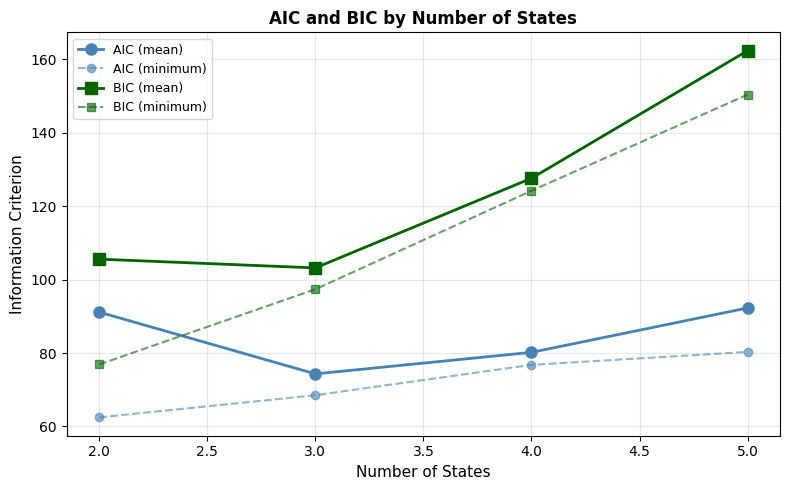

In [23]:
plotar_aic_bic_por_estados(df_aic_bic)

### Gaussian Distribution per State

In [26]:
def plotar_distribuicoes_estados_gaussianhmm(resultado_grid_val, criterio='melhor_nrmse', n_std=3, num_points=1000, figsize=(12, 8)):
    """
    Visualizes the Gaussian distributions (mean and variance) of each hidden state
    of the best GaussianHMM model obtained via grid search.
    
    Args:
        resultado_grid_val: dict returned by grid_search_gaussianhmm_validacao containing:
            - 'nome': series name
            - 'melhor_nrmse', 'melhor_rmse', 'melhor_acuracia', etc.: best models
        criterio: which best model to use ('melhor_nrmse', 'melhor_rmse', 'melhor_acuracia', 'melhor_mae', 'melhor_correlacao')
        n_std: number of standard deviations for X-axis range
        num_points: resolution of PDF curves
        figsize: figure size
    
    Returns:
        None (displays the chart)
    
    Example:
        >>> resultado_grid_val = grid_search_gaussianhmm_validacao(...)
        >>> plotar_distribuicoes_estados_gaussianhmm(resultado_grid_val, criterio='melhor_nrmse')
    """
    import scipy.stats as stats
    
    # Validate criterion
    criterios_validos = ['melhor_nrmse', 'melhor_rmse', 'melhor_acuracia', 'melhor_mae', 'melhor_correlacao']
    if criterio not in criterios_validos:
        raise ValueError(f"criterio must be one of {criterios_validos}, received '{criterio}'")
    
    # Extract best model
    resultado_alvo = resultado_grid_val[criterio]
    modelo_hmm = resultado_alvo['modelo']
    n_estados = resultado_alvo['n_estados']
    nome_serie = resultado_grid_val['nome']
    
    # Extract means and variances of each state
    medias = modelo_hmm.means_.flatten()
    variancias = modelo_hmm.covars_.flatten()
    desvios_padrao = np.sqrt(variancias)
    
    # Configure X-axis (range of transformed series values)
    x_min = np.min(medias - n_std * desvios_padrao)
    x_max = np.max(medias + n_std * desvios_padrao)
    x_axis = np.linspace(x_min, x_max, num_points)
    
    # Colors for each state
    cores = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'cyan', 'magenta']
    
    # Create figure
    plt.figure(figsize=figsize)
    
    # Plot Gaussian curve for each state
    for i in range(n_estados):
        mu = medias[i]
        sigma = desvios_padrao[i]
        var = variancias[i]
        
        # Calculate PDF (Probability Density Function)
        y_axis = stats.norm.pdf(x_axis, mu, sigma)
        
        # Draw curve
        plt.plot(x_axis, y_axis, color=cores[i % len(cores)], lw=2.5, 
                label=f'State {i}: $\\mu$={mu:.4f}, $\\sigma^2$={var:.4f}')
        
        # Fill area under curve
        plt.fill_between(x_axis, y_axis, alpha=0.2, color=cores[i % len(cores)])
        
        # Mark mean with vertical dashed line
        plt.axvline(mu, color=cores[i % len(cores)], linestyle='--', alpha=0.5, linewidth=1)
    
    # Aesthetic settings
    plt.title(f"Hidden State Distributions - Gaussian HMM ({n_estados} States)\nSeries: {nome_serie}", 
             fontsize=14, fontweight='bold')
    plt.xlabel("Observation Value (e.g., Log-Return)", fontsize=12)
    plt.ylabel("Probability Density", fontsize=12)
    plt.legend(loc='upper right', fontsize=10, framealpha=0.9)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    
    plt.show()
    
    # Print statistical summary
    print("\n" + "="*70)
    print("GAUSSIAN HMM - STATE STATISTICS")
    print("="*70)
    print(f"Model: {criterio}")
    print(f"Series: {nome_serie}")
    print(f"Number of States: {n_estados}")
    print("\n--- State Parameters ---")
    for i in range(n_estados):
        print(f"\nState {i}:")
        print(f"  Mean (μ):      {medias[i]:.6f}")
        print(f"  Variance (σ²): {variancias[i]:.6f}")
        print(f"  Std Dev (σ):   {desvios_padrao[i]:.6f}")
    print("="*70)


In [27]:
def plotar_distribuicoes_estados_melhor_aic(resultado_grid_val, df_aic_bic, n_estados_alvo=3, n_std=3, num_points=1000, figsize=(12, 8)):
    """
    Visualizes the Gaussian distributions (mean and variance) of each hidden state
    of the GaussianHMM model with the lowest AIC among models with n_estados_alvo states.

    Args:
        resultado_grid_val: dict returned by grid_search_gaussianhmm_validacao containing:
            - 'nome': series name
            - 'todos_resultados': list with all grid search results
        df_aic_bic: DataFrame returned by calcular_aic_bic, used to identify the
                    model with the lowest AIC (columns: n_estados, random_state, aic)
        n_estados_alvo: number of states to filter before selecting the lowest AIC (default: 3)
        n_std: number of standard deviations for X-axis range
        num_points: resolution of PDF curves
        figsize: figure size

    Returns:
        None (displays the chart)

    Example:
        >>> df_aic_bic = calcular_aic_bic(resultado_grid_val)
        >>> plotar_distribuicoes_estados_melhor_aic(resultado_grid_val, df_aic_bic, n_estados_alvo=3)
    """
    import scipy.stats as stats

    # Filter only models with the target number of states
    df_filtrado = df_aic_bic[df_aic_bic['n_estados'] == n_estados_alvo]

    if df_filtrado.empty:
        raise ValueError(
            f"No models with n_estados={n_estados_alvo} found in df_aic_bic. "
            f"Available values: {sorted(df_aic_bic['n_estados'].unique().tolist())}"
        )

    # Identify the row with the lowest AIC among the filtered models
    idx_melhor = df_filtrado['aic'].idxmin()
    melhor = df_filtrado.loc[idx_melhor]
    n_estados = int(melhor['n_estados'])
    random_state = int(melhor['random_state'])
    nome_serie = resultado_grid_val['nome']

    # Recover the transformed series from todos_resultados
    serie_transformada = None
    for res in resultado_grid_val['todos_resultados']:
        if (res['resultado_completo']['n_estados'] == n_estados and
                res['random_state'] == random_state):
            serie_transformada = res['resultado_completo']['serie_transformada']
            break

    if serie_transformada is None:
        raise ValueError(
            f"Could not find the model with n_estados={n_estados} and "
            f"random_state={random_state} in todos_resultados."
        )

    # Retrain the model on the full series (same settings as calcular_aic_bic)
    obs_sequencia = serie_transformada.to_numpy()
    modelo_hmm = hmm.GaussianHMM(
        n_components=n_estados,
        covariance_type='full',
        n_iter=100,
        random_state=random_state,
        verbose=False
    )
    modelo_hmm.fit(obs_sequencia.reshape(-1, 1))

    # Extract means and variances of each state
    medias = modelo_hmm.means_.flatten()
    variancias = modelo_hmm.covars_.flatten()
    desvios_padrao = np.sqrt(variancias)

    # Configure X-axis
    x_min = np.min(medias - n_std * desvios_padrao)
    x_max = np.max(medias + n_std * desvios_padrao)
    x_axis = np.linspace(x_min, x_max, num_points)

    # Colors for each state
    cores = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'cyan', 'magenta']

    # Create figure
    plt.figure(figsize=figsize)

    # Plot Gaussian curve for each state
    for i in range(n_estados):
        mu = medias[i]
        sigma = desvios_padrao[i]
        var = variancias[i]

        y_axis = stats.norm.pdf(x_axis, mu, sigma)

        plt.plot(x_axis, y_axis, color=cores[i % len(cores)], lw=2.5,
                 label=f'State {i}: $\\mu$={mu:.4f}, $\\sigma^2$={var:.4f}')
        plt.fill_between(x_axis, y_axis, alpha=0.2, color=cores[i % len(cores)])
        plt.axvline(mu, color=cores[i % len(cores)], linestyle='--', alpha=0.5, linewidth=1)

    plt.title(
        f"Hidden State Distributions - Gaussian HMM ({n_estados} States) — Best AIC\n"
        f"Series: {nome_serie}  |  AIC: {melhor['aic']:.2f}  |  Seed: {random_state}",
        fontsize=14, fontweight='bold'
    )
    plt.xlabel("Observation Value (e.g., Log-Return)", fontsize=12)
    plt.ylabel("Probability Density", fontsize=12)
    plt.legend(loc='upper right', fontsize=10, framealpha=0.9)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()

    # Print statistical summary
    print("\n" + "="*70)
    print(f"GAUSSIAN HMM - STATE STATISTICS (Best AIC | {n_estados} States)")
    print("="*70)
    print(f"Criterion: lowest AIC among models with {n_estados} states")
    print(f"Series: {nome_serie}")
    print(f"Number of States: {n_estados}")
    print(f"AIC:   {melhor['aic']:.4f}")
    print(f"BIC:   {melhor['bic']:.4f}")
    print(f"NRMSE: {melhor['nrmse']:.4f}")
    print(f"Seed:  {random_state}")
    print("\n--- State Parameters ---")
    for i in range(n_estados):
        print(f"\nState {i}:")
        print(f"  Mean (μ):      {medias[i]:.6f}")
        print(f"  Variance (σ²): {variancias[i]:.6f}")
        print(f"  Std Dev (σ):   {desvios_padrao[i]:.6f}")
    print("="*70)

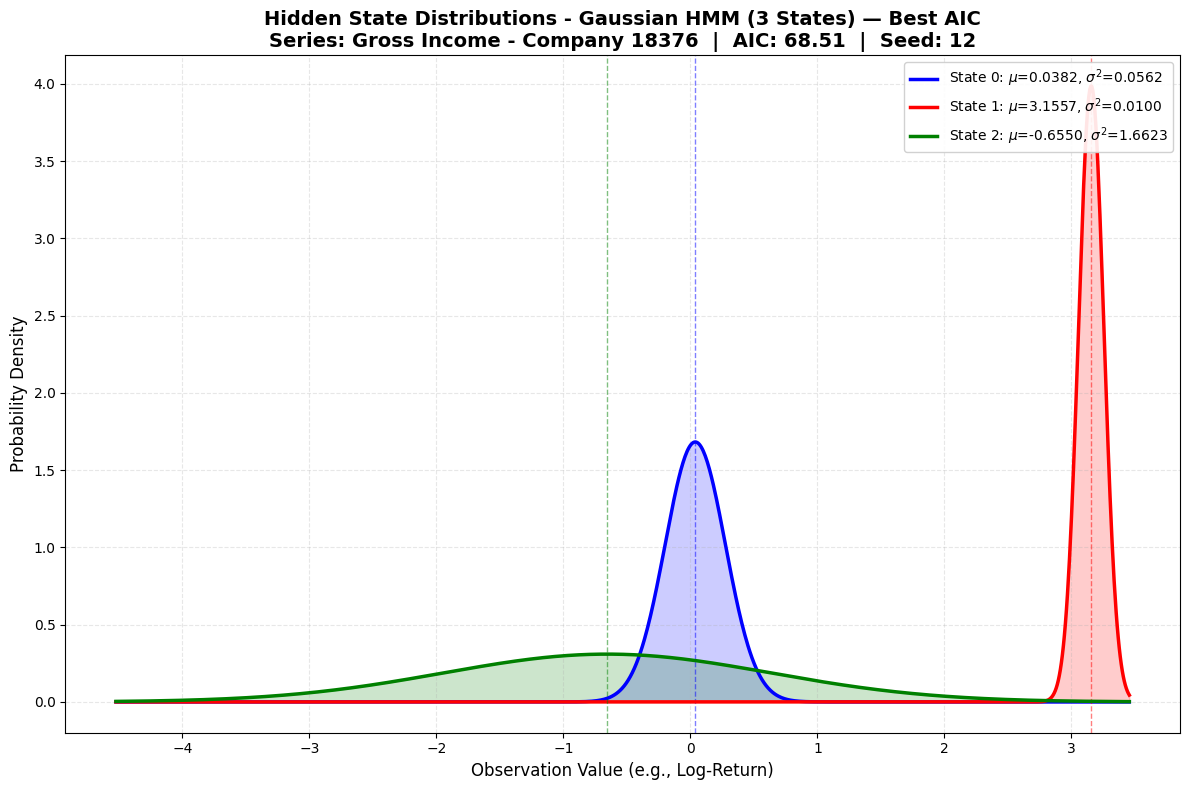


GAUSSIAN HMM - STATE STATISTICS (Best AIC | 3 States)
Criterion: lowest AIC among models with 3 states
Series: Gross Income - Company 18376
Number of States: 3
AIC:   68.5096
BIC:   97.3558
NRMSE: 0.1419
Seed:  12

--- State Parameters ---

State 0:
  Mean (μ):      0.038206
  Variance (σ²): 0.056234
  Std Dev (σ):   0.237137

State 1:
  Mean (μ):      3.155656
  Variance (σ²): 0.010010
  Std Dev (σ):   0.100050

State 2:
  Mean (μ):      -0.654982
  Variance (σ²): 1.662286
  Std Dev (σ):   1.289297


In [28]:
plotar_distribuicoes_estados_melhor_aic(resultado_grid_val, df_aic_bic)

## GMM-HMM

In [ ]:
def gmmhmm_one_step_ahead(serie, nome_serie='Series', n_estados=3, n_mix=2, janela_treino=18,
                          aplicar_log=True, diferenciacao=1, n_iter=100, random_states=None):
    """
    Trains GMMHMM with one-step-ahead validation testing multiple random states
    and returns the best result (lowest NRMSE).
    """
    # Prepare series
    serie_transformada, serie_original, transformacoes = preparar_serie_gaussianhmm(
        serie, aplicar_log, diferenciacao
    )

    # Test stationarity
    teste_estacionariedade = testar_estacionariedade(serie_transformada, nome_serie)

    obs_sequencia = serie_transformada.to_numpy()
    index_obs = serie_transformada.index

    if len(obs_sequencia) <= janela_treino:
        raise ValueError(f"Series has only {len(obs_sequencia)} observations. Required > {janela_treino}")

    # Seeds: 20 random if no list provided
    if random_states is None:
        np.random.seed(42)
        random_states = np.random.randint(1, 10000, size=20).tolist()

    melhor_nrmse = np.inf
    melhor_resultado = None
    resultados_seeds = []

    print(f"\n{'='*70}")
    print(f"ONE-STEP-AHEAD GMMHMM - {nome_serie}")
    print(f"{'='*70}")
    print(f"Number of states: {n_estados}")
    print(f"Gaussian components per state: {n_mix}")
    print(f"Initial training window: {janela_treino} observations")
    print(f"Total predictions (out-of-sample): {len(obs_sequencia) - janela_treino}")
    print(f"Transformations: {' → '.join(transformacoes)}")
    print(f"Stationary series: {'✔ YES' if teste_estacionariedade['conclusao_estacionaria'] else '✗ NO'}")
    print(f"Seeds tested: {random_states}")
    print('='*70)

    for seed in random_states:
        estados_reais = []
        estados_preditos = []
        valores_reais = []
        valores_preditos = []
        probabilidades = []
        indices = []

        for i in range(janela_treino, len(obs_sequencia)):
            treino = obs_sequencia[:i].reshape(-1, 1)

            model = hmm.GMMHMM(
                n_components=n_estados,
                n_mix=n_mix,
                covariance_type='diag',
                n_iter=n_iter,
                min_covar=0.1,
                random_state=seed,
                verbose=False
            )

            try:
                model.fit(treino)

                # Decode states of training set
                _, estados_treino = model.decode(treino)
                estado_atual = estados_treino[-1]

                # Predict next state using transition matrix
                probs_prox_estado = model.transmat_[estado_atual]
                estado_predito = int(np.argmax(probs_prox_estado))

                # Predict next value using weighted mean of Gaussians for predicted state
                medias_estado = model.means_[estado_predito]    # shape: (n_mix, n_features)
                pesos_estado = model.weights_[estado_predito]   # shape: (n_mix,)
                valor_predito = np.sum(pesos_estado * medias_estado[:, 0])

                # Real value (out-of-sample)
                valor_real = obs_sequencia[i]

                # Store results
                estados_reais.append(estado_atual)
                estados_preditos.append(estado_predito)
                valores_reais.append(valor_real)
                valores_preditos.append(valor_predito)
                probabilidades.append(probs_prox_estado[estado_predito])
                indices.append(index_obs[i])

            except Exception as e:
                print(f"[seed={seed}] Error at iteration {i}: {str(e)}")
                continue

        if len(valores_reais) == 0:
            continue

        # Metrics for this seed
        valores_reais_arr = np.array(valores_reais)
        valores_preditos_arr = np.array(valores_preditos)

        mse = mean_squared_error(valores_reais_arr, valores_preditos_arr)
        rmse_bruto = np.sqrt(mse)
        faixa = valores_reais_arr.max() - valores_reais_arr.min()
        nrmse = rmse_bruto / faixa if faixa != 0 else np.nan
        mae = np.mean(np.abs(valores_reais_arr - valores_preditos_arr))
        correlacao = np.corrcoef(valores_reais_arr, valores_preditos_arr)[0, 1] if len(valores_reais) > 1 else np.nan
        acuracia_estados = accuracy_score(estados_reais, estados_preditos)

        resultados_seeds.append({
            'seed': seed,
            'nrmse': nrmse,
            'mae': mae,
            'correlacao': correlacao,
            'acuracia_estados': acuracia_estados
        })

        print(f"[seed={seed:5d}] Acc={acuracia_estados:.3f} | NRMSE={nrmse:.4f} | MAE={mae:.4f} | Corr={correlacao:.3f}")

        if np.isnan(nrmse):
            continue

        if nrmse < melhor_nrmse:
            melhor_nrmse = nrmse
            df_resultados = pd.DataFrame({
                'estado_atual': estados_reais,
                'estado_predito': estados_preditos,
                'valor_real': valores_reais,
                'valor_predito': valores_preditos,
                'probabilidade': probabilidades
            }, index=indices)

            melhor_resultado = {
                'nome': nome_serie,
                'serie_original': serie_original,
                'serie_transformada': serie_transformada,
                'transformacoes': transformacoes,
                'teste_estacionariedade': teste_estacionariedade,
                'df_resultados': df_resultados,
                'metricas': {
                    'acuracia_estados': acuracia_estados,
                    'nrmse': nrmse,
                    'rmse_bruto': rmse_bruto,
                    'mae': mae,
                    'correlacao': correlacao,
                    'n_predicoes': len(df_resultados)
                },
                'n_estados': n_estados,
                'n_mix': n_mix,
                'janela_treino': janela_treino,
                'melhor_seed': seed,
                'seeds_testados': random_states
            }

    if melhor_resultado is None:
        raise ValueError("No predictions were made!")

    print(f"\n{'='*70}")
    print("BEST MODEL (lowest NRMSE)")
    print('='*70)
    print(f"Seed: {melhor_resultado['melhor_seed']}")
    print(f"State Accuracy: {melhor_resultado['metricas']['acuracia_estados']:.4f}")
    print(f"NRMSE: {melhor_resultado['metricas']['nrmse']:.4f}")
    print(f"MAE: {melhor_resultado['metricas']['mae']:.4f}")
    print(f"Correlation: {melhor_resultado['metricas']['correlacao']:.4f}")
    print('='*70)

    melhor_resultado['resultados_seeds'] = pd.DataFrame(resultados_seeds).sort_values('nrmse')
    return melhor_resultado

def grid_search_gmmhmm_validacao(serie, nome_serie='Series', 
                                 estados_range=(2, 6),
                                 mix_range=(2, 5),
                                 janela_treino=18,
                                 n_iter=100, 
                                 random_states=None,
                                 aplicar_log=True, 
                                 diferenciacao=1):
    """
    Grid search for GMMHMM with one-step-ahead validation.
    
    Tests multiple combinations of:
    - Number of hidden states
    - Number of Gaussian components per state
    - Random seeds
    
    Args:
        serie: original time series
        nome_serie: series name
        estados_range: tuple (min, max) for number of states
        mix_range: tuple (min, max) for number of Gaussian components
        janela_treino: number of initial observations for training
        n_iter: Baum-Welch iterations
        random_states: list of seeds
        aplicar_log: apply logarithm
        diferenciacao: differentiation order
    
    Returns:
        dict with results and best models
    """
    if random_states is None:
        np.random.seed(42)
        random_states = np.random.randint(1, 1000, size=5).tolist()
    
    print(f"\n{'='*70}")
    print(f"GMMHMM GRID SEARCH WITH VALIDATION - {nome_serie}")
    print(f"{'='*70}")
    print(f"States: {list(range(estados_range[0], estados_range[1]))}")
    print(f"Gaussian Components: {list(range(mix_range[0], mix_range[1]))}")
    print(f"Seeds: {random_states}")
    print(f"Training window: {janela_treino}")
    print(f"Total combinations: {len(range(estados_range[0], estados_range[1])) * len(range(mix_range[0], mix_range[1])) * len(random_states)}")
    print('='*70)
    
    resultados = []
    
    for n_estados in range(estados_range[0], estados_range[1]):
        for n_mix in range(mix_range[0], mix_range[1]):
            try:
                resultado = gmmhmm_one_step_ahead(
                    serie=serie,
                    nome_serie=nome_serie,
                    n_estados=n_estados,
                    n_mix=n_mix,
                    janela_treino=janela_treino,
                    aplicar_log=aplicar_log,
                    diferenciacao=diferenciacao,
                    n_iter=n_iter,
                    random_states=random_states
                )
                
                resultados.append({
                    'n_estados': n_estados,
                    'n_mix': n_mix,
                    'random_state': random_states,
                    'acuracia_estados': resultado['metricas']['acuracia_estados'],
                    'nrmse': resultado['metricas']['nrmse'],
                    'mae': resultado['metricas']['mae'],
                    'correlacao': resultado['metricas']['correlacao'],
                    'resultado_completo': resultado
                })
                
                print(f"\nStates={n_estados}, Mix={n_mix}, Seed={random_states:3d} → "
                        f"Acc={resultado['metricas']['acuracia_estados']:.3f}, "
                        f"NRMSE={resultado['metricas']['nrmse']:.4f}, "
                        f"MAE={resultado['metricas']['mae']:.4f}, "
                        f"Corr={resultado['metricas']['correlacao']:.3f}")
                
            except Exception as e:
                print(f"\nStates={n_estados}, Mix={n_mix}, Seed={random_states} → ERROR: {str(e)}")
                continue

    if not resultados:
        raise ValueError("No model was successfully trained!")
    
    # Create DataFrame with results
    df_resultados = pd.DataFrame([
        {
            'n_estados': r['n_estados'],
            'n_mix': r['n_mix'],
            'random_state': r['random_state'],
            'acuracia_estados': r['acuracia_estados'],
            'nrmse': r['nrmse'],
            'mae': r['mae'],
            'correlacao': r['correlacao']
        }
        for r in resultados
    ])
    
    # Identify best models
    melhor_acuracia_idx = df_resultados['acuracia_estados'].idxmax()
    melhor_nrmse_idx = df_resultados['nrmse'].idxmin()
    melhor_mae_idx = df_resultados['mae'].idxmin()
    melhor_correlacao_idx = df_resultados['correlacao'].idxmax()
    
    melhor_acuracia = resultados[melhor_acuracia_idx]['resultado_completo']
    melhor_nrmse = resultados[melhor_nrmse_idx]['resultado_completo']
    melhor_mae = resultados[melhor_mae_idx]['resultado_completo']
    melhor_correlacao = resultados[melhor_correlacao_idx]['resultado_completo']
    
    print(f"\n{'='*70}")
    print("RESULTS SUMMARY")
    print('='*70)
    print(f"\n✔ BEST MODEL BY STATE ACCURACY:")
    print(f"  States: {melhor_acuracia['n_estados']}, Mix: {melhor_acuracia['n_mix']}")
    print(f"  Accuracy: {melhor_acuracia['metricas']['acuracia_estados']:.4f}")
    print(f"  NRMSE: {melhor_acuracia['metricas']['nrmse']:.4f}")
    
    print(f"\n✔ BEST MODEL BY NRMSE:")
    print(f"  States: {melhor_nrmse['n_estados']}, Mix: {melhor_nrmse['n_mix']}")
    print(f"  NRMSE: {melhor_nrmse['metricas']['nrmse']:.4f}")
    print(f"  Accuracy: {melhor_nrmse['metricas']['acuracia_estados']:.4f}")
    
    print(f"\n✔ BEST MODEL BY MAE:")
    print(f"  States: {melhor_mae['n_estados']}, Mix: {melhor_mae['n_mix']}")
    print(f"  MAE: {melhor_mae['metricas']['mae']:.4f}")
    print(f"  NRMSE: {melhor_mae['metricas']['nrmse']:.4f}")
    
    print(f"\n✔ BEST MODEL BY CORRELATION:")
    print(f"  States: {melhor_correlacao['n_estados']}, Mix: {melhor_correlacao['n_mix']}")
    print(f"  Correlation: {melhor_correlacao['metricas']['correlacao']:.4f}")
    print(f"  NRMSE: {melhor_correlacao['metricas']['nrmse']:.4f}")
    print('='*70)
    
    return {
        'nome': nome_serie,
        'df_resultados': df_resultados,
        'todos_resultados': resultados,
        'melhor_acuracia': melhor_acuracia,
        'melhor_nrmse': melhor_nrmse,
        'melhor_mae': melhor_mae,
        'melhor_correlacao': melhor_correlacao
    }

def plotar_comparacao_gmmhmm(resultado_validacao, figsize=(15, 8)):
    """
    Plots:
      1) Real vs predicted values on the transformed series (log-return)
      2) Predicted values converted back to original scale vs real series
    """
    # If grid search result, extract best model by NRMSE
    if 'melhor_nrmse' in resultado_validacao:
        resultado_validacao = resultado_validacao['melhor_nrmse']
        
    df = resultado_validacao['df_resultados'].copy()
    metricas = resultado_validacao['metricas']
    serie_original = resultado_validacao['serie_original']
    idx_original = serie_original.index

    # Convert predictions back (log-return -> original level): p_hat_t = p_{t-1} * exp(r_hat)
    pred_orig = []
    real_orig = []
    for t, r_hat in zip(df.index, df['valor_predito']):
        try:
            pos = idx_original.get_loc(t)
            if pos > 0:
                p_prev = serie_original.iloc[pos - 1]
                pred_orig.append(p_prev * np.exp(r_hat))
            else:
                pred_orig.append(np.nan)
            real_orig.append(serie_original.iloc[pos])
        except Exception:
            pred_orig.append(np.nan)
            real_orig.append(np.nan)

    df['valor_predito_orig'] = pred_orig
    df['valor_real_orig'] = real_orig

    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True)
    fig.subplots_adjust(hspace=0.25)

    # 1) Transformed series (log-returns)
    ax1 = axes[0]
    ax1.plot(df.index, df['valor_real'], 'o-', color='navy', linewidth=1.5, markersize=4,
             label='Real Value (log-ret)', alpha=0.7)
    ax1.plot(df.index, df['valor_predito'], 's--', color='crimson', linewidth=1.5, markersize=4,
             label='Predicted Value (log-ret)', alpha=0.7)
    ax1.set_title(f"Transformed (log-return) - NRMSE: {metricas.get('nrmse', np.nan):.4f}",
                  fontsize=12, fontweight='bold')
    ax1.set_ylabel('Log-return', fontsize=11)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2) Original scale
    ax2 = axes[1]
    ax2.plot(df.index, df['valor_real_orig'], 'o-', color='steelblue', linewidth=1.5, markersize=4,
             label='Real Value (orig)', alpha=0.7)
    ax2.plot(df.index, df['valor_predito_orig'], 's--', color='darkorange', linewidth=1.5, markersize=4,
             label='Predicted Value (orig)', alpha=0.7)
    ax2.set_title("Original Scale (reconstructed from log-return)", fontsize=12, fontweight='bold')
    ax2.set_xlabel('Time', fontsize=11)
    ax2.set_ylabel('Value', fontsize=11)
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


In [ ]:
# Single test
empresa_analise = '20257'

print("="*70)
print("SINGLE TEST - GMMHMM")
print("="*70)

resultado_gmmhmm = gmmhmm_one_step_ahead(
    serie=lucro_consolidado[empresa_analise],
    nome_serie=f'Gross Profit - Company {empresa_analise}',
    n_estados=2,
    n_mix=2,
    janela_treino=25,
    aplicar_log=True,
    diferenciacao=1,
    n_iter=100,
    random_states=[1, 3, 5, 7, 9, 11, 13, 15, 17, 19,
                   21, 23, 25, 27, 29, 31, 33, 35, 37, 39]
)


In [ ]:
# Plot (reuses GaussianHMM function)
plotar_validacao_gaussianhmm(resultado_gmmhmm)


In [ ]:
# Full grid search
print("\n\n" + "="*70)
print("GRID SEARCH - GMMHMM")
print("="*70)
empresa_analise = '20257'
resultado_grid_gmmhmm = grid_search_gmmhmm_validacao(
    serie=resultado_bruto[empresa_analise],
    nome_serie=f'Gross Income - Company {empresa_analise}',
    estados_range=(2, 5),  # 2, 3, 4 states
    mix_range=(2, 4),      # 2, 3 components
    janela_treino=35,
    n_iter=100,
    random_states=[1, 42, 99, 150, 200],
    aplicar_log=True,
    diferenciacao=1
)

# Display summary table
print("\n=== TOP 10 MODELS BY NRMSE ===")
display(resultado_grid_gmmhmm['df_resultados'].sort_values('nrmse').head(10))

print("\n=== TOP 10 MODELS BY ACCURACY ===")
display(resultado_grid_gmmhmm['df_resultados'].sort_values('acuracia_estados', ascending=False).head(10))


In [ ]:
# Plot comparisons
plotar_comparacao_gmmhmm(resultado_grid_gmmhmm)

# Plot best model
print("\n\nPLOTTING BEST MODEL BY NRMSE")
plotar_validacao_gaussianhmm(resultado_grid_gmmhmm['melhor_nrmse'])
